In [1]:
#Task 1
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
cols = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15','A16']

df = pd.read_csv(url, names=cols, na_values='?')

df['A2'] = pd.to_numeric(df['A2'])
df['A14'] = pd.to_numeric(df['A14'])

print("Data Types:\n", df.dtypes)

df.head(10)


Data Types:
 A1      object
A2     float64
A3     float64
A4      object
A5      object
A6      object
A7      object
A8     float64
A9      object
A10     object
A11      int64
A12     object
A13     object
A14    float64
A15      int64
A16     object
dtype: object


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.250,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.040,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.500,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.750,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.710,t,f,0,f,s,120.0,0,+
5,b,32.08,4.000,u,g,m,v,2.500,t,f,0,t,g,360.0,0,+
6,b,33.17,1.040,u,g,r,h,6.500,t,f,0,t,g,164.0,31285,+
7,a,22.92,11.585,u,g,cc,v,0.040,t,f,0,f,g,80.0,1349,+
8,b,54.42,0.500,y,p,k,h,3.960,t,f,0,f,g,180.0,314,+
9,b,42.50,4.915,y,p,w,v,3.165,t,f,0,t,g,52.0,1442,+


In [2]:
#Task 2
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [3]:
for col in num_cols:
    df[col] =  df[col].fillna(df[col].median())

In [4]:
for col in cat_cols:
    df[col]= df[col].fillna(df[col].mode()[0])

In [5]:
print("Missing values after imputation")
print(df.isnull().sum())

Missing values after imputation
A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

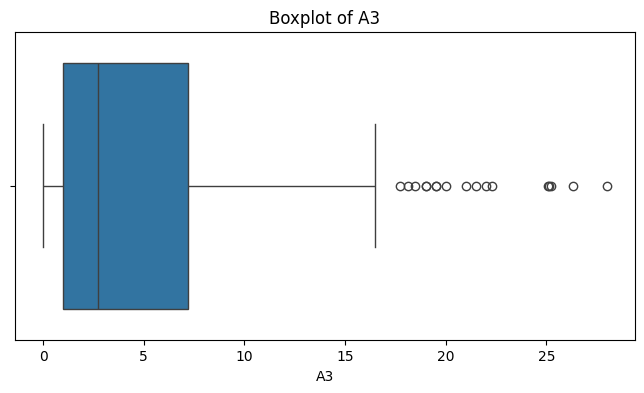

In [6]:
#Task 3
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=df['A3'])
plt.title("Boxplot of A3")
plt.show


In [7]:
#Task 4
df = pd.get_dummies(df, columns=['A1'], drop_first=True)

In [10]:
# Min-Max Normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head(10)

,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16,A1_b
0,0.256842,0.000000,u,g,w,v,0.043860,t,t,0.014925,f,g,0.1010,0.00000,+,True
1,0.675489,0.159286,u,g,q,h,0.106667,t,t,0.089552,f,g,0.0215,0.00560,+,False
2,0.161654,0.017857,u,g,q,h,0.052632,t,f,0.000000,f,g,0.1400,0.00824,+,False
3,0.211729,0.055000,u,g,w,v,0.131579,t,t,0.074627,t,g,0.0500,0.00003,+,True
4,0.096541,0.200893,u,g,w,v,0.060000,t,f,0.000000,f,s,0.0600,0.00000,+,True
5,0.275639,0.142857,u,g,m,v,0.087719,t,f,0.000000,t,g,0.1800,0.00000,+,True
6,0.292030,0.037143,u,g,r,h,0.228070,t,f,0.000000,t,g,0.0820,0.31285,+,True
7,0.137895,0.413750,u,g,cc,v,0.001404,t,f,0.000000,f,g,0.0400,0.01349,+,False
8,0.611579,0.017857,y,p,k,h,0.138947,t,f,0.000000,f,g,0.0900,0.00314,+,True
9,0.432331,0.175536,y,p,w,v,0.111053,t,f,0.000000,t,g,0.0260,0.01442,+,True
